In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

# Load your uploaded file (change name if needed)
df = pd.read_csv('/content/iris (1) (1).csv')

# Features & target (assumes last column is label)
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train models
lin = SVC(kernel='linear').fit(X_train, y_train)
rbf = SVC(kernel='rbf').fit(X_train, y_train)

# Predictions
y_lin = lin.predict(X_test)
y_rbf = rbf.predict(X_test)

# Output
print("Linear Acc:", accuracy_score(y_test, y_lin))
print(confusion_matrix(y_test, y_lin))

print("\nRBF Acc:", accuracy_score(y_test, y_rbf))
print(confusion_matrix(y_test, y_rbf))

Linear Acc: 1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

RBF Acc: 1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


Accuracy: 0.711
Confusion Matrix:
 [[132   0   0   0   0   0   0   0   0   4   1   0   3   0   0   0   0   2
    3   1   0   0   1   1   1   0]
 [  1 114   0   6   2   1   1   5   1   0   0   0   0   0   4   2   1   8
    2   0   0   1   0   4   0   0]
 [  0   0 102   0   4   0   0   4   0   0  10   3   0   1   1   0   5   0
    1   2   2   1   1   0   0   0]
 [  0   1   0 125   0   1   1   4   0   6   1   2   3   0   2   2   0   1
    0   3   0   0   0   3   0   1]
 [  0   3  15   0  79   2   1   0   3   0   9   1   0   0   0   0   6   7
    3   1   2   0   0   3   0   6]
 [  0   6   0   1   2  96   1   3   2   1   1   0   0   0   1  10   1   1
    3   7   0   0   2   1   0   1]
 [  0   3  37   1   1   0  50   3   1   0   4   6   0   0   1   0  35   8
    7   0   0   0   2   1   0   0]
 [  3   4   0   8   0   3   0  39   0   0   7   1   6  23   9   3   3  16
    0   1  10   0   0   6   2   0]
 [  0   3   0   3   0   0   0   0 120   4   1   1   0   0   0   1   0   1
    4   0   0   0  

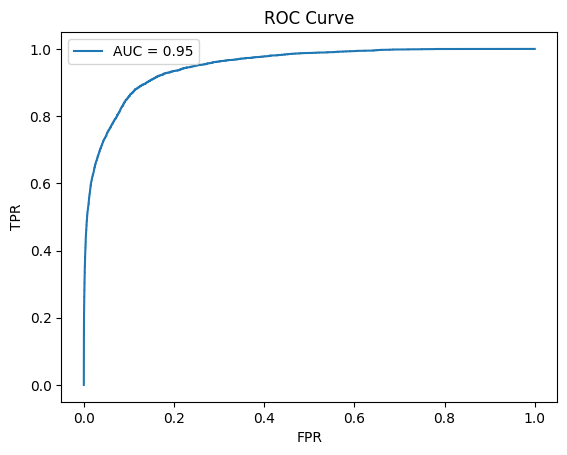

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Load dataset (use header!)
df = pd.read_csv('/content/letter-recognition.csv')

# First column = label, rest = features
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

# Binarize labels
classes = sorted(y.unique())
y_bin = label_binarize(y, classes=classes)

# Split 80/20
X_train, X_test, y_train, y_test, y_train_bin, y_test_bin = train_test_split(
    X, y, y_bin, test_size=0.2, random_state=42)

# Train model
model = LinearSVC()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
y_score = model.decision_function(X_test)

# Accuracy & confusion matrix
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ROC + AUC
fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()